**Week 2 — Exploratory Data Analysis: NextGenLearners Applicant Insights**

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('applicants_cleaned.csv', parse_dates=['Application Date'])
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Applicant Name    65 non-null     object        
 1   Email             65 non-null     object        
 2   Phone             65 non-null     int64         
 3   Domain Applied    65 non-null     object        
 4   University        65 non-null     object        
 5   Application Date  64 non-null     datetime64[ns]
 6   Status            65 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 3.7+ KB


,Applicant Name,Email,Phone,Domain Applied,University,Application Date,Status
0,Bob Davis,bob.davis@example.com,1651623197,Web Development,Columbia,2021-04-02,Active
1,Bob Brown,bob.brown@example.com,1898471390,Data Science,Harvard University,2020-07-10,Active
2,Eva Davis,eva.davis@example.com,3476490784,Cybersecurity,Yale,2021-11-27,Inactive
3,Frank Williams,frank.williams@example.com,1586734256,Cloud Computing,Cambridge,2022-01-05,Active
4,Alice Garcia,alice.garcia@example.com,5409003485,Web Development,Cambridge,2020-06-10,Inactive


Domain Applied
Web Development     21
Data Science        14
Cloud Computing     12
Cybersecurity       11
Machine Learning     7
Name: count, dtype: int64


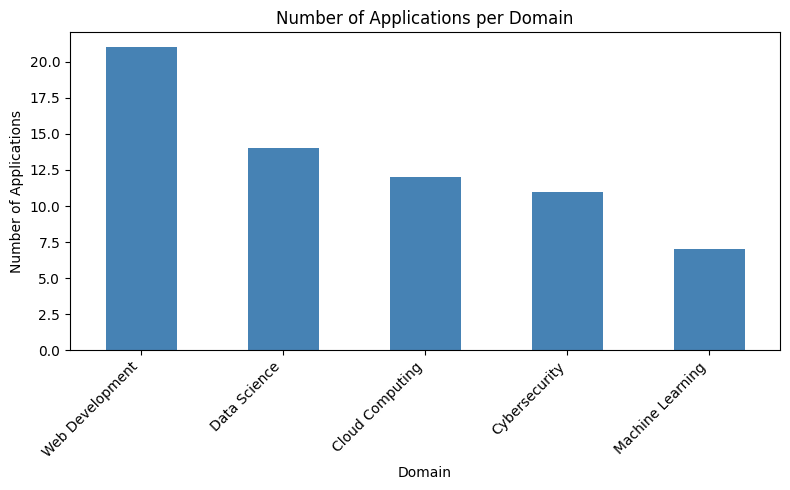

In [7]:
domain_counts = df['Domain Applied'].value_counts()
print(domain_counts)
plt.figure(figsize=(8,5))
domain_counts.plot(kind='bar', color='steelblue')
plt.title('Number of Applications per Domain')
plt.xlabel('Domain')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Web Development received the highest number of applications, while Machine Learning received the fewest.

Application Month
2020-01    2
2020-02    1
2020-04    3
2020-06    1
2020-07    2
2020-09    2
2020-10    2
2021-02    1
2021-03    4
2021-04    2
2021-05    3
2021-07    1
2021-08    1
2021-11    2
2022-01    4
2022-02    1
2022-05    2
2022-07    2
2022-09    1
2022-12    1
2023-01    1
2023-05    2
2023-07    1
2023-08    2
2023-09    3
2023-10    1
2023-11    2
2024-01    1
2024-03    2
2024-04    1
2024-06    3
2024-07    1
2024-09    1
2024-11    4
2024-12    1
Freq: M, dtype: int64


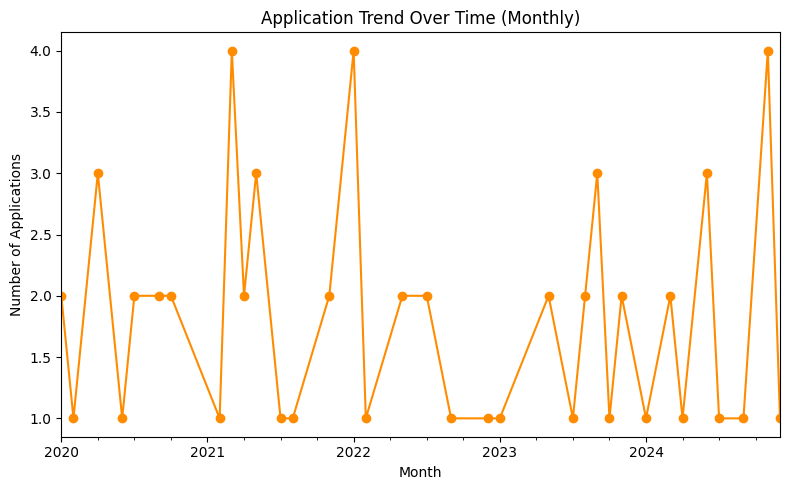

In [8]:
df['Application Month'] = df['Application Date'].dt.to_period('M')
monthly_trend = df.groupby('Application Month').size()
print(monthly_trend)
plt.figure(figsize=(8,5))
monthly_trend.plot(kind='line', marker='o', color='darkorange')
plt.title('Application Trend Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.tight_layout()
plt.show()

Applications were received consistently between 2020 and 2024, with no clear long-term increasing or decreasing trend. The highest monthly application counts were 4, observed in March 2021, January 2022, and November 2024, while most months recorded 1–2 applications, indicating a fairly steady application pattern with a few moderate peaks.

Status
Active          25
Pending         20
Inactive        17
Under Review     3
Name: count, dtype: int64
Status            Active  Inactive  Pending  Under Review
Domain Applied                                           
Cloud Computing        3         2        5             2
Cybersecurity          5         4        2             0
Data Science           5         3        6             0
Machine Learning       4         2        1             0
Web Development        8         6        6             1


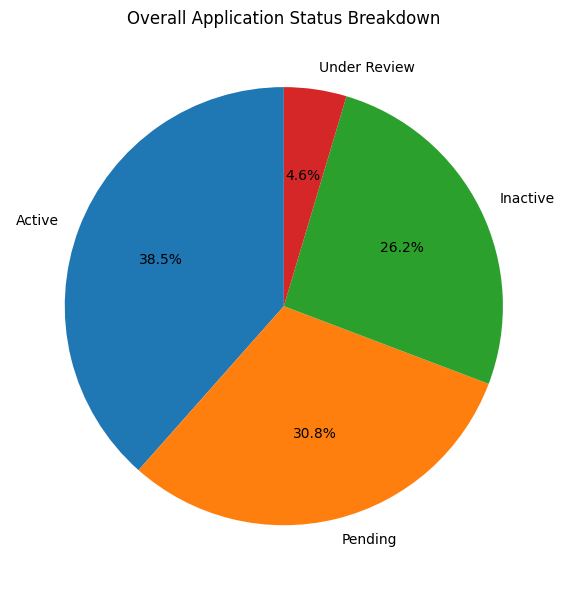

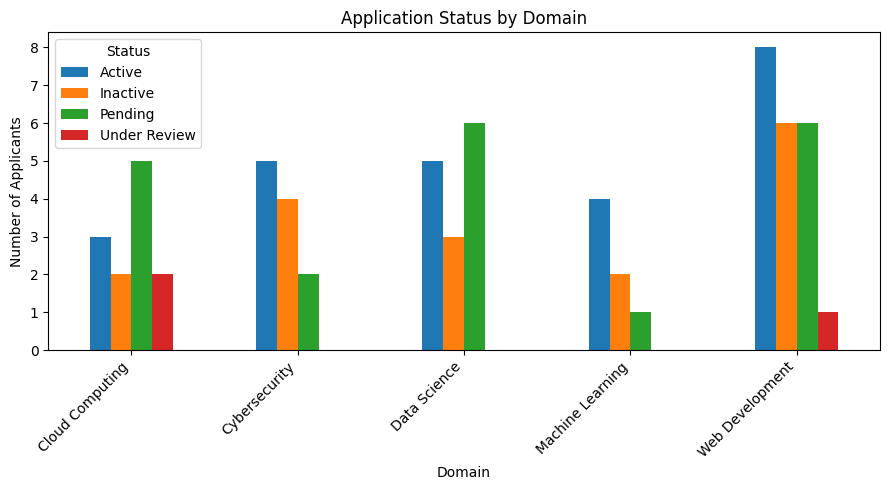

In [9]:
status_counts = df['Status'].value_counts()
print(status_counts)
status_by_domain = pd.pivot_table(
df, index='Domain Applied', columns='Status', values='Applicant Name', aggfunc='count', fill_value=0
)
print(status_by_domain)
# Overall status - pie chart
plt.figure(figsize=(6,6))
status_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Overall Application Status Breakdown')
plt.ylabel('') # removes the default awkward y-label pie charts add
plt.tight_layout()
plt.show()
# Per-domain - grouped bar chart
status_by_domain.plot(kind='bar', figsize=(9,5))
plt.title('Application Status by Domain')
plt.xlabel('Domain')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

Some domains have higher acceptance rates than others despite receiving fewer applications.

University
Yale                  12
Harvard University    11
Cambridge              8
Stanford               8
Princeton              6
Columbia               5
Chicago                4
Oxford                 4
Not Specified          4
MIT                    2
Name: count, dtype: int64


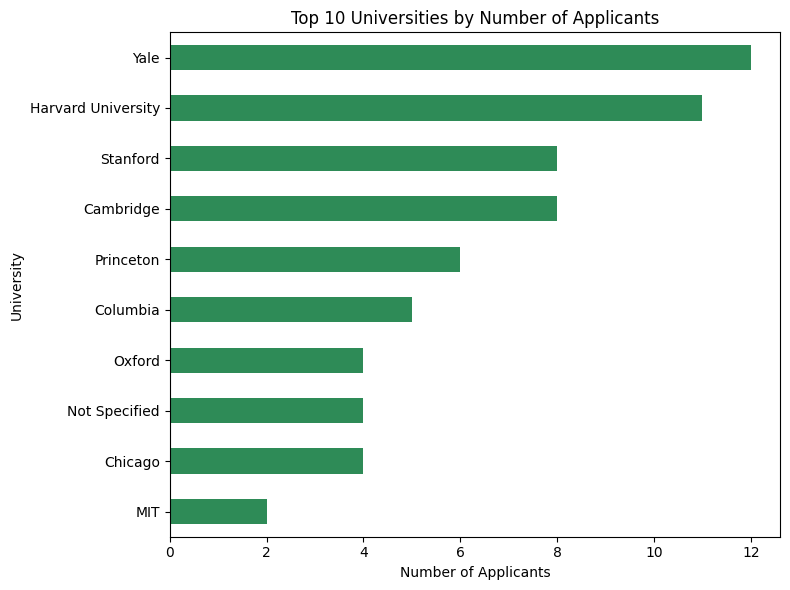

In [10]:
top_universities = df['University'].value_counts().head(10)
print(top_universities)
plt.figure(figsize=(8,6))
top_universities.sort_values().plot(kind='barh', color='seagreen')
plt.title('Top 10 Universities by Number of Applicants')
plt.xlabel('Number of Applicants')
plt.ylabel('University')
plt.tight_layout()
plt.show()

The top few universities contributed a large share of total applicatio

Day
Monday        8
Tuesday      15
Wednesday    10
Thursday     10
Friday        5
Saturday     11
Sunday        5
Name: count, dtype: int64


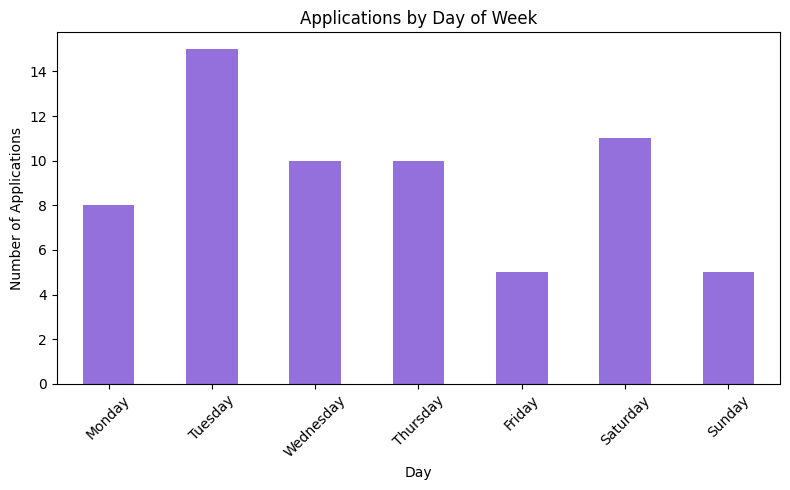

In [11]:
df["Day"] = df["Application Date"].dt.day_name()

day_counts = df["Day"].value_counts()

days = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_counts = day_counts.reindex(days)

print(day_counts)

plt.figure(figsize=(8,5))

day_counts.plot(
    kind="bar",
    color="mediumpurple"
)

plt.title("Applications by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Applications")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

I chose Applications by Day of Week analysis to determine whether applicants tend to submit applications more frequently on certain days of the week. Most applications were submitted during tuesday, with fewer submissions on weekends

Top 5 Universities:
University
Yale                  12
Harvard University    11
Cambridge              8
Stanford               8
Princeton              6
Name: count, dtype: int64
University Group  Other Universities  Top 5 Universities
Domain Applied                                          
Cloud Computing                    5                   7
Cybersecurity                      2                   9
Data Science                       5                   9
Machine Learning                   1                   6
Web Development                    7                  14


<Figure size 1000x600 with 0 Axes>

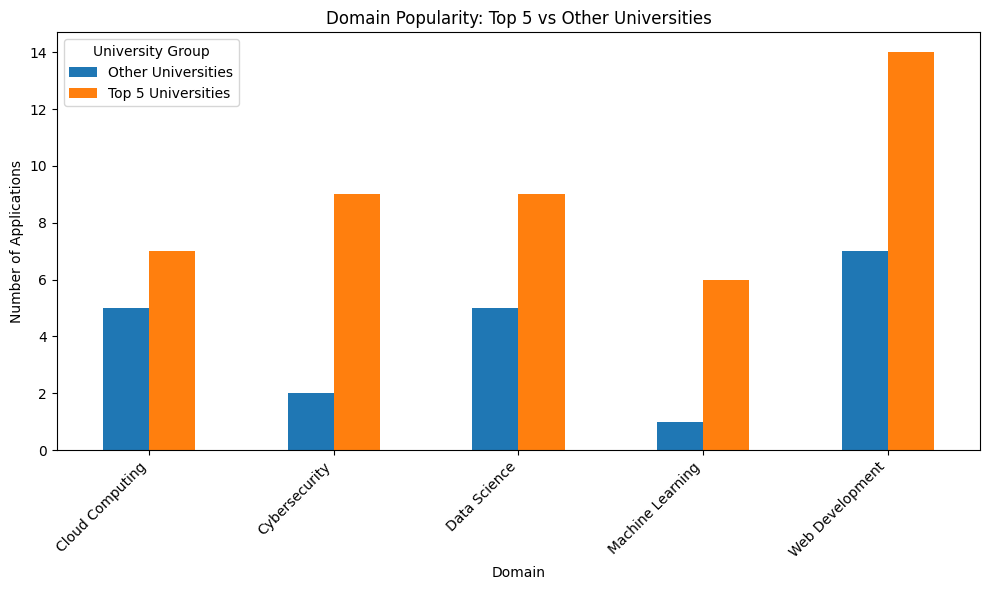

In [13]:
# Find the top 5 universities by number of applicants
top5_universities = df["University"].value_counts().head(5).index

# Create a new group
df["University Group"] = df["University"].apply(
    lambda x: "Top 5 Universities" if x in top5_universities else "Other Universities"
)
print("Top 5 Universities:")
print(df['University'].value_counts().head(5))

# Count applications by domain and university group
domain_compare = pd.crosstab(
    df["Domain Applied"],
    df["University Group"]
)

print(domain_compare)
plt.figure(figsize=(10,6))

domain_compare.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Domain Popularity: Top 5 vs Other Universities")
plt.xlabel("Domain")
plt.ylabel("Number of Applications")
plt.xticks(rotation=45, ha="right")
plt.legend(title="University Group")

plt.tight_layout()
plt.show()

I chose domains comparison to identify which is popular among applicants from the top universities versus all other universities. This comparison helps identify whether application preferences differ between applicants from the most represented universities and everyone else. Applicants from the top five universities generally followed the same domain preferences as other universities, although some domains attracted proportionally more applicants from the top universities.

Summary Statistics:
count      64.000000
mean     1501.828125
std       564.963282
min       603.000000
25%      1023.250000
50%      1583.500000
75%      1954.500000
max      2390.000000
Name: Application Age (Days), dtype: float64


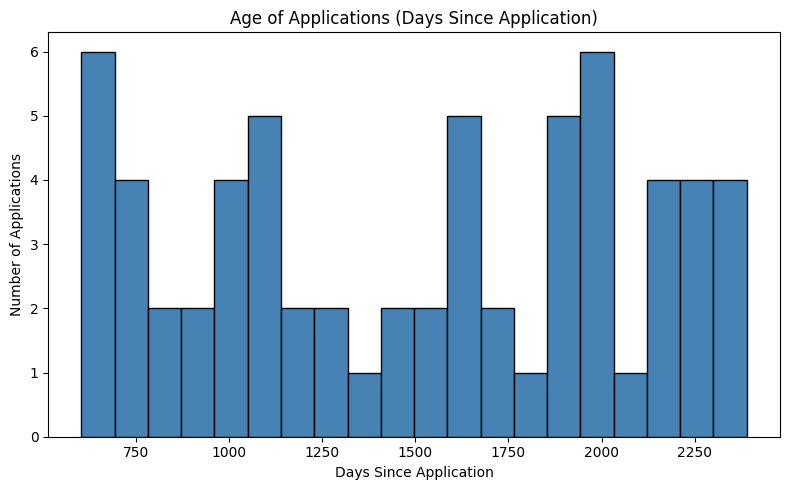

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Today's date
today = pd.Timestamp.today().normalize()

# Calculate age of each application in days
df['Application Age (Days)'] = (today - df['Application Date']).dt.days

# Summary statistics
print("Summary Statistics:")
print(df['Application Age (Days)'].describe())

# Plot
plt.figure(figsize=(8,5))
plt.hist(df['Application Age (Days)'], bins=20, color='steelblue', edgecolor='black')

plt.title('Age of Applications (Days Since Application)')
plt.xlabel('Days Since Application')
plt.ylabel('Number of Applications')

plt.tight_layout()
plt.show()

I use analysis of average time between application date and todaywanted to examine how recent the applications are. Understanding application freshness helps identify whether most applicants applied recently or whether the dataset mainly contains older applications.

## Key Insights

- The application data shows that interest is spread across multiple domains, although some domains received noticeably more applications than others. This can help identify areas with the highest applicant demand.  Web Development is the most popular domain than other domain.

- Applications were received consistently between 2020 and 2024, with small peaks in a few months rather than one large recruitment surge. This suggests applications were submitted throughout the available time period instead of being concentrated in a single campaign.

- Acceptance rates vary across domains, indicating that application volume alone does not determine the likelihood of selection. Comparing percentages provides a fairer assessment than comparing raw counts.

- A relatively small number of universities contributed a large share of applicants. Focusing future outreach efforts on these universities while expanding promotion to underrepresented institutions could improve both application volume and diversity.

- Overall, the exploratory analysis provides useful decision-support for planning future recruitment by identifying application trends, domain popularity, and the institutions that contribute the most applicants.
